# Amazon Last-Mile Delivery — Time Prediction & Late Delivery Detection

**Dataset:** Amazon Delivery Dataset (Kaggle) — real deliveries  
**Models:** LightGBM regression (delivery time) + LightGBM classifier (late delivery risk)  
**Skills:** Feature engineering, regression modeling, classification modeling, cross-validation, statistical testing, SHAP explainability


In [1]:
# Cell 1 — Install dependencies
!pip install lightgbm shap -q

In [2]:
# Cell 2 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import lightgbm as lgb
import shap
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    roc_auc_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_curve
)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded successfully')

Libraries loaded successfully


In [6]:
from google.colab import files
import os

# Step 1: Upload kaggle.json
print("Upload your kaggle.json file:")
uploaded = files.upload()

# Step 2: Set up credentials
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(list(uploaded.values())[0])
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle credentials set up successfully")

# Step 3: Download dataset
!kaggle datasets download -d sujalsuthar/amazon-delivery-dataset --unzip

# Step 4: Load CSV
import glob
import pandas as pd
csv_files = glob.glob('*.csv')
print('Files found:', csv_files)
df_raw = pd.read_csv(csv_files[0])
print('Columns:', df_raw.columns.tolist())
print('Shape:', df_raw.shape)
df_raw.head(3)

Upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
Kaggle credentials set up successfully
Dataset URL: https://www.kaggle.com/datasets/sujalsuthar/amazon-delivery-dataset
License(s): MIT
100% 1.53M/1.53M [00:00<00:00, 166MB/s]

Files found: ['amazon_delivery.csv']
Columns: ['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']
Shape: (43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports


In [7]:
# Cell 4 — Data cleaning and feature engineering

df = df_raw.copy()

# Target
target_col = 'Delivery_Time'
df = df.dropna(subset=[target_col])
df = df[df[target_col] > 0]
df[target_col] = df[target_col].astype(float)

# Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

df['distance_km'] = haversine(
    df['Store_Latitude'], df['Store_Longitude'],
    df['Drop_Latitude'],  df['Drop_Longitude']
)

# Time features
df['Order_Time']  = pd.to_datetime(df['Order_Time'],  format='%H:%M:%S', errors='coerce')
df['Pickup_Time'] = pd.to_datetime(df['Pickup_Time'], format='%H:%M:%S', errors='coerce')
df['pickup_lag_min'] = (df['Pickup_Time'] - df['Order_Time']).dt.total_seconds() / 60
df['pickup_lag_min'] = df['pickup_lag_min'].clip(0, 120).fillna(df['pickup_lag_min'].median())
df['order_hour']  = df['Order_Time'].dt.hour
df['Order_Date']  = pd.to_datetime(df['Order_Date'], errors='coerce')
df['order_dow']   = df['Order_Date'].dt.dayofweek
df['order_month'] = df['Order_Date'].dt.month
df['is_weekend']  = (df['order_dow'] >= 5).astype(int)
df['is_rushhour'] = df['order_hour'].isin([7,8,9,17,18,19]).astype(int)

# Encode categoricals
cat_cols = ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print(f'Clean dataset: {len(df):,} rows')
print(f'Delivery time — mean: {df[target_col].mean():.1f} min | std: {df[target_col].std():.1f} min')
df[[target_col, 'distance_km', 'pickup_lag_min', 'order_hour']].describe()

Clean dataset: 43,739 rows
Delivery time — mean: 124.9 min | std: 51.9 min


,Delivery_Time,distance_km,pickup_lag_min,order_hour
count,43739.000000,43739.000000,43739.000000,43648.000000
mean,124.905645,38.561752,9.768970,17.425976
std,51.915451,534.564299,4.264025,4.818494
min,10.000000,1.465067,0.000000,0.000000
25%,90.000000,4.663432,5.000000,15.000000
50%,125.000000,9.220450,10.000000,19.000000
75%,160.000000,13.682379,15.000000,21.000000
max,270.000000,19692.674606,15.000000,23.000000


In [8]:
print(df_raw.columns.tolist())

['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']


In [9]:
# Cell 5 — Build feature set and define labels

FEATURE_COLS = [
    'Agent_Age', 'Agent_Rating', 'distance_km',
    'pickup_lag_min', 'order_hour', 'order_dow', 'order_month',
    'is_weekend', 'is_rushhour',
    'Weather_enc', 'Traffic_enc', 'Vehicle_enc', 'Area_enc', 'Category_enc'
]

X     = df[FEATURE_COLS].fillna(-1)
y_reg = df[target_col]

# Late delivery: actual time > mean + 1.5 std
threshold = y_reg.mean() + 1.5 * y_reg.std()
y_clf = (y_reg > threshold).astype(int)

print(f'Features: {len(FEATURE_COLS)}')
print(f'Total samples: {len(X):,}')
print(f'Mean delivery time: {y_reg.mean():.1f} min')
print(f'Late threshold: {threshold:.1f} min')
print(f'Late delivery rate: {y_clf.mean():.1%}')
print(f'Class imbalance ratio: {(y_clf==0).sum()/(y_clf==1).sum():.1f}:1')

Features: 14
Total samples: 43,739
Mean delivery time: 124.9 min
Late threshold: 202.8 min
Late delivery rate: 8.3%
Class imbalance ratio: 11.1:1


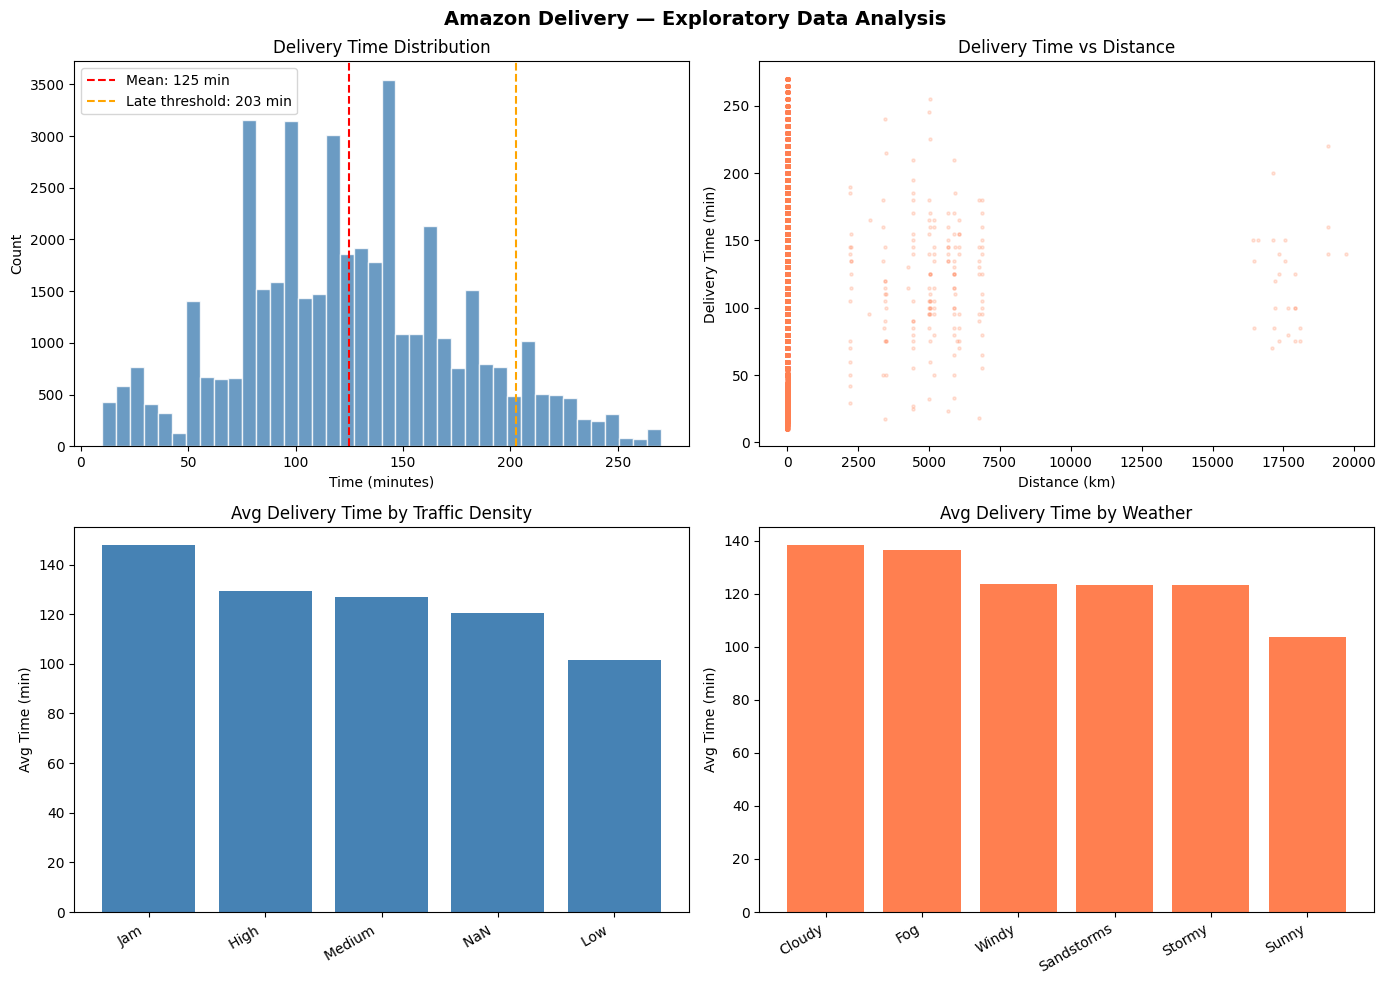

ANOVA — Traffic vs delivery time: F=1669.59, p=0.00e+00 => Significant
ANOVA — Weather vs delivery time: F=432.97, p=0.00e+00 => Significant
Pearson — Agent rating vs delivery time: r=-0.260, p=0.00e+00 => Significant


In [10]:
# Cell 6 — Exploratory Data Analysis

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Amazon Delivery — Exploratory Data Analysis', fontsize=14, fontweight='bold')

# 1. Delivery time distribution
axes[0,0].hist(y_reg, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(y_reg.mean(), color='red', linestyle='--', label=f'Mean: {y_reg.mean():.0f} min')
axes[0,0].axvline(threshold, color='orange', linestyle='--', label=f'Late threshold: {threshold:.0f} min')
axes[0,0].set_title('Delivery Time Distribution')
axes[0,0].set_xlabel('Time (minutes)')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# 2. Delivery time vs distance
axes[0,1].scatter(df['distance_km'], y_reg, alpha=0.2, s=5, color='coral')
axes[0,1].set_title('Delivery Time vs Distance')
axes[0,1].set_xlabel('Distance (km)')
axes[0,1].set_ylabel('Delivery Time (min)')

# 3. Average delivery time by traffic
traffic_avg = df.groupby('Traffic')[target_col].mean().sort_values(ascending=False)
axes[1,0].bar(range(len(traffic_avg)), traffic_avg.values, color='steelblue')
axes[1,0].set_xticks(range(len(traffic_avg)))
axes[1,0].set_xticklabels(traffic_avg.index, rotation=30, ha='right')
axes[1,0].set_title('Avg Delivery Time by Traffic Density')
axes[1,0].set_ylabel('Avg Time (min)')

# 4. Average delivery time by weather
weather_avg = df.groupby('Weather')[target_col].mean().sort_values(ascending=False)
axes[1,1].bar(range(len(weather_avg)), weather_avg.values, color='coral')
axes[1,1].set_xticks(range(len(weather_avg)))
axes[1,1].set_xticklabels(weather_avg.index, rotation=30, ha='right')
axes[1,1].set_title('Avg Delivery Time by Weather')
axes[1,1].set_ylabel('Avg Time (min)')

plt.tight_layout()
plt.show()

# Statistical tests
traffic_groups = [group[target_col].values for _, group in df.groupby('Traffic')]
f1_, p1 = stats.f_oneway(*traffic_groups)
print(f'ANOVA — Traffic vs delivery time: F={f1_:.2f}, p={p1:.2e} => {"Significant" if p1<0.05 else "Not significant"}')

weather_groups = [group[target_col].values for _, group in df.groupby('Weather')]
f2_, p2 = stats.f_oneway(*weather_groups)
print(f'ANOVA — Weather vs delivery time: F={f2_:.2f}, p={p2:.2e} => {"Significant" if p2<0.05 else "Not significant"}')

corr, p_corr = stats.pearsonr(df['Agent_Rating'].fillna(0), y_reg)
print(f'Pearson — Agent rating vs delivery time: r={corr:.3f}, p={p_corr:.2e} => {"Significant" if p_corr<0.05 else "Not significant"}')

In [11]:
# Cell 7 — Train/test split

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

scale_pos_weight = (y_clf_train==0).sum() / (y_clf_train==1).sum()

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Late rate — train: {y_clf_train.mean():.1%} | test: {y_clf_test.mean():.1%}')
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

Train: 34,991 | Test: 8,748
Late rate — train: 8.3% | test: 8.0%
scale_pos_weight: 11.0


In [12]:
# Cell 8 — Model 1: Delivery Time Regression (LightGBM)

eta_model = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=63, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
)

eta_model.fit(X_train, y_reg_train)
y_pred_reg = eta_model.predict(X_test)

mae     = mean_absolute_error(y_reg_test, y_pred_reg)
rmse    = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
within5 = np.mean(np.abs(y_reg_test - y_pred_reg) <= 5) * 100
within10= np.mean(np.abs(y_reg_test - y_pred_reg) <= 10) * 100

cv_scores = cross_val_score(eta_model, X_train, y_reg_train,
                              cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
cv_mae = -cv_scores.mean()

print('=' * 50)
print('DELIVERY TIME REGRESSION RESULTS')
print('=' * 50)
print(f'MAE:               {mae:.2f} minutes')
print(f'RMSE:              {rmse:.2f} minutes')
print(f'Within +/-5 min:   {within5:.1f}%')
print(f'Within +/-10 min:  {within10:.1f}%')
print(f'5-Fold CV MAE:     {cv_mae:.2f} minutes')

DELIVERY TIME REGRESSION RESULTS
MAE:               17.28 minutes
RMSE:              22.09 minutes
Within +/-5 min:   19.1%
Within +/-10 min:  36.7%
5-Fold CV MAE:     17.61 minutes


In [13]:
# Cell 9 — Model 2: Late Delivery Classifier (LightGBM + class imbalance handling)

exc_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    num_leaves=63, min_child_samples=20, subsample=0.8,
    colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    random_state=42, n_jobs=-1, verbose=-1
)

exc_model.fit(X_train, y_clf_train)
y_pred_proba = exc_model.predict_proba(X_test)[:,1]
y_pred_clf   = (y_pred_proba > 0.5).astype(int)

auc       = roc_auc_score(y_clf_test, y_pred_proba)
precision = precision_score(y_clf_test, y_pred_clf)
recall    = recall_score(y_clf_test, y_pred_clf)
f1        = f1_score(y_clf_test, y_pred_clf)

cv_auc = cross_val_score(exc_model, X_train, y_clf_train,
                          cv=5, scoring='roc_auc', n_jobs=-1)

print('=' * 50)
print('LATE DELIVERY CLASSIFIER RESULTS')
print('=' * 50)
print(f'ROC-AUC:           {auc:.3f}')
print(f'Precision:         {precision:.3f}')
print(f'Recall:            {recall:.3f}')
print(f'F1-Score:          {f1:.3f}')
print(f'5-Fold CV AUC:     {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}')
print()
print(classification_report(y_clf_test, y_pred_clf, target_names=['On-Time','Late']))

LATE DELIVERY CLASSIFIER RESULTS
ROC-AUC:           0.964
Precision:         0.436
Recall:            0.904
F1-Score:          0.589
5-Fold CV AUC:     0.957 +/- 0.002

              precision    recall  f1-score   support

     On-Time       0.99      0.90      0.94      8051
        Late       0.44      0.90      0.59       697

    accuracy                           0.90      8748
   macro avg       0.71      0.90      0.77      8748
weighted avg       0.95      0.90      0.91      8748



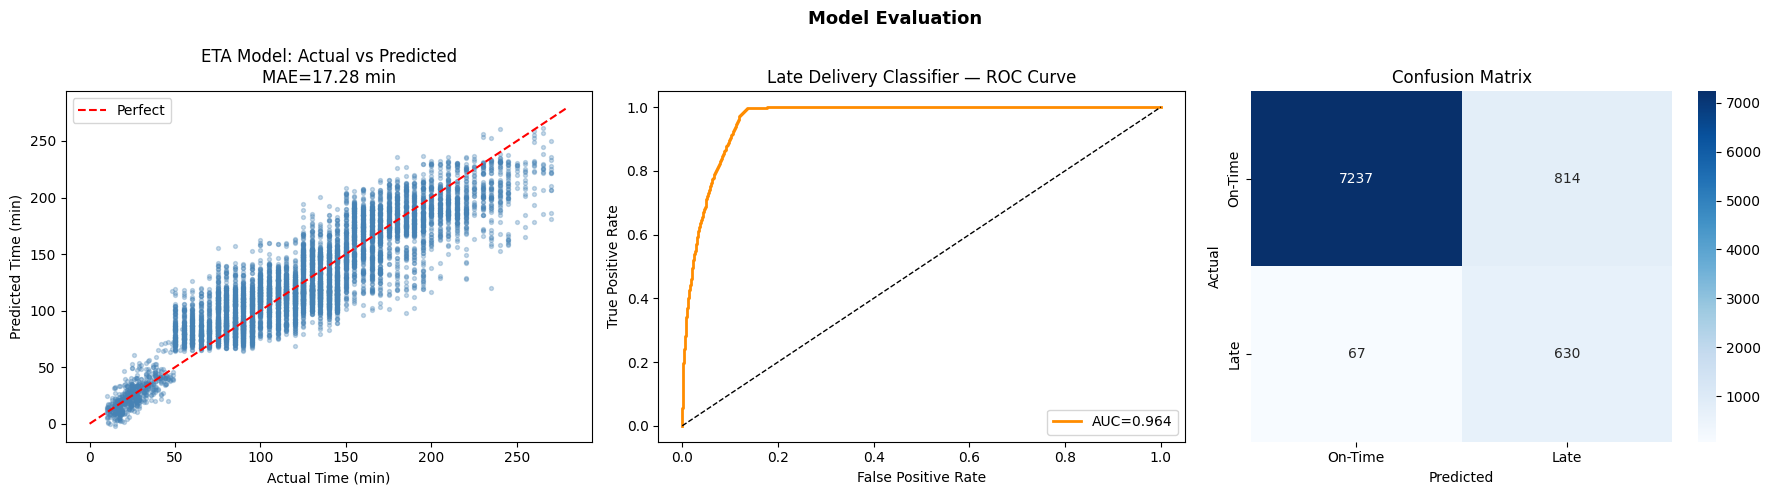

In [14]:
# Cell 10 — Evaluation plots

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontsize=13, fontweight='bold')

# 1. Actual vs Predicted
axes[0].scatter(y_reg_test, y_pred_reg, alpha=0.3, s=8, color='steelblue')
lim = max(y_reg_test.max(), y_pred_reg.max()) + 10
axes[0].plot([0,lim],[0,lim],'r--', linewidth=1.5, label='Perfect')
axes[0].set_xlabel('Actual Time (min)')
axes[0].set_ylabel('Predicted Time (min)')
axes[0].set_title(f'ETA Model: Actual vs Predicted\nMAE={mae:.2f} min')
axes[0].legend()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_clf_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Late Delivery Classifier — ROC Curve')
axes[1].legend()

# 3. Confusion matrix
cm = confusion_matrix(y_clf_test, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['On-Time','Late'],
            yticklabels=['On-Time','Late'])
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

Computing SHAP values...


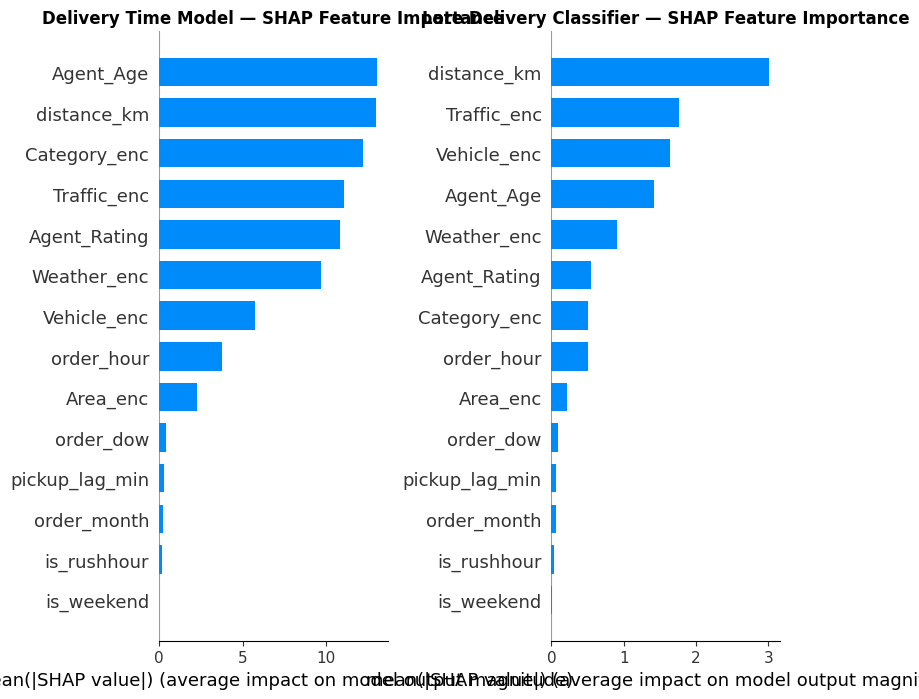

In [15]:
# Cell 11 — SHAP Feature Importance

print('Computing SHAP values...')

explainer_reg = shap.TreeExplainer(eta_model)
shap_vals_reg = explainer_reg.shap_values(X_test)

explainer_clf = shap.TreeExplainer(exc_model)
shap_vals_clf = explainer_clf.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_vals_reg, X_test, feature_names=FEATURE_COLS,
                   plot_type='bar', show=False)
axes[0].set_title('Delivery Time Model — SHAP Feature Importance', fontweight='bold')

plt.sca(axes[1])
shap_clf_vals = shap_vals_clf[1] if isinstance(shap_vals_clf, list) else shap_vals_clf
shap.summary_plot(shap_clf_vals, X_test, feature_names=FEATURE_COLS,
                   plot_type='bar', show=False)
axes[1].set_title('Late Delivery Classifier — SHAP Feature Importance', fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# Cell 12 — Statistical business insights

print('=' * 55)
print('STATISTICAL ANALYSIS — KEY BUSINESS INSIGHTS')
print('=' * 55)

# 1. Traffic impact
print('\n1. Avg delivery time by traffic density:')
for name, group in df.groupby('Traffic'):
    print(f'   {name}: {group[target_col].mean():.1f} min')
traffic_groups = [g[target_col].values for _, g in df.groupby('Traffic')]
f_, p_ = stats.f_oneway(*traffic_groups)
print(f'   ANOVA p={p_:.2e} => {"Significant" if p_<0.05 else "Not significant"}')

# 2. Weather impact
print('\n2. Avg delivery time by weather:')
for name, group in df.groupby('Weather'):
    print(f'   {name}: {group[target_col].mean():.1f} min')
weather_groups = [g[target_col].values for _, g in df.groupby('Weather')]
f2_, p2_ = stats.f_oneway(*weather_groups)
print(f'   ANOVA p={p2_:.2e} => {"Significant" if p2_<0.05 else "Not significant"}')

# 3. Agent rating correlation
corr, p_corr = stats.pearsonr(df['Agent_Rating'].fillna(0), y_reg)
print(f'\n3. Agent rating vs delivery time:')
print(f'   Pearson r={corr:.3f}, p={p_corr:.2e} => {"Significant" if p_corr<0.05 else "Not significant"}')

# 4. Pickup lag impact
corr2, p_corr2 = stats.pearsonr(df['pickup_lag_min'], y_reg)
print(f'\n4. Pickup lag vs delivery time:')
print(f'   Pearson r={corr2:.3f}, p={p_corr2:.2e} => {"Significant" if p_corr2<0.05 else "Not significant"}')

STATISTICAL ANALYSIS — KEY BUSINESS INSIGHTS

1. Avg delivery time by traffic density:
   High : 129.4 min
   Jam : 147.8 min
   Low : 101.4 min
   Medium : 126.8 min
   NaN : 120.7 min
   ANOVA p=0.00e+00 => Significant

2. Avg delivery time by weather:
   Cloudy: 138.3 min
   Fog: 136.6 min
   Sandstorms: 123.2 min
   Stormy: 123.2 min
   Sunny: 103.7 min
   Windy: 123.7 min
   ANOVA p=0.00e+00 => Significant

3. Agent rating vs delivery time:
   Pearson r=-0.260, p=0.00e+00 => Significant

4. Pickup lag vs delivery time:
   Pearson r=0.009, p=5.23e-02 => Not significant


In [17]:
# Cell 13 — Final Model Summary

print('=' * 55)
print('FINAL MODEL SUMMARY')
print('=' * 55)
print(f'Dataset:              Amazon Delivery Dataset (Kaggle)')
print(f'Total deliveries:     {len(df):,}')
print(f'Features used:        {len(FEATURE_COLS)}')
print(f'Late delivery rate:   {y_clf.mean():.1%}')
print()
print('DELIVERY TIME REGRESSION (LightGBM):')
print(f'  MAE:                {mae:.2f} minutes')
print(f'  RMSE:               {rmse:.2f} minutes')
print(f'  Within +/-5 min:    {within5:.1f}%')
print(f'  Within +/-10 min:   {within10:.1f}%')
print(f'  5-Fold CV MAE:      {cv_mae:.2f} minutes')
print()
print('LATE DELIVERY CLASSIFIER (LightGBM + scale_pos_weight):')
print(f'  ROC-AUC:            {auc:.3f}')
print(f'  Precision:          {precision:.3f}')
print(f'  Recall:             {recall:.3f}')
print(f'  F1-Score:           {f1:.3f}')
print(f'  5-Fold CV AUC:      {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}')

FINAL MODEL SUMMARY
Dataset:              Amazon Delivery Dataset (Kaggle)
Total deliveries:     43,739
Features used:        14
Late delivery rate:   8.3%

DELIVERY TIME REGRESSION (LightGBM):
  MAE:                17.28 minutes
  RMSE:               22.09 minutes
  Within +/-5 min:    19.1%
  Within +/-10 min:   36.7%
  5-Fold CV MAE:      17.61 minutes

LATE DELIVERY CLASSIFIER (LightGBM + scale_pos_weight):
  ROC-AUC:            0.964
  Precision:          0.436
  Recall:             0.904
  F1-Score:           0.589
  5-Fold CV AUC:      0.957 +/- 0.002


In [19]:
# Cell 14 — Live Prediction Widget

import ipywidgets as widgets
from IPython.display import display, clear_output

_style  = {'description_width': '180px'}
_layout = widgets.Layout(width='440px')

distance_w  = widgets.FloatSlider(value=5.0, min=0.1, max=50.0, step=0.5,
                                   description='Distance (km):', style=_style, layout=_layout)
rating_w    = widgets.FloatSlider(value=4.5, min=1.0, max=5.0, step=0.1,
                                   description='Agent Rating:', style=_style, layout=_layout)
age_w       = widgets.IntSlider(value=28, min=18, max=60,
                                 description='Agent Age:', style=_style, layout=_layout)
pickup_w    = widgets.IntSlider(value=10, min=0, max=60,
                                 description='Pickup lag (min):', style=_style, layout=_layout)
weather_w   = widgets.Dropdown(options=sorted(df['Weather'].dropna().unique().tolist()),
                                description='Weather:', style=_style, layout=_layout)
traffic_w   = widgets.Dropdown(options=sorted(df['Traffic'].dropna().unique().tolist()),
                                description='Traffic:', style=_style, layout=_layout)
area_w      = widgets.Dropdown(options=sorted(df['Area'].dropna().unique().tolist()),
                                description='Area:', style=_style, layout=_layout)
hour_w      = widgets.IntSlider(value=14, min=0, max=23,
                                 description='Order hour:', style=_style, layout=_layout)

output = widgets.Output()

def on_predict(b):
    with output:
        clear_output(wait=True)
        def enc(col, val):
            try: return int(le_dict[col].transform([val])[0])
            except: return -1

        row = {
            'Agent_Age':       age_w.value,
            'Agent_Rating':    rating_w.value,
            'distance_km':     distance_w.value,
            'pickup_lag_min':  pickup_w.value,
            'order_hour':      hour_w.value,
            'order_dow':       0,
            'order_month':     6,
            'is_weekend':      0,
            'is_rushhour':     int(hour_w.value in [7,8,9,17,18,19]),
            'Weather_enc':     enc('Weather',  weather_w.value),
            'Traffic_enc':     enc('Traffic',  traffic_w.value),
            'Vehicle_enc':     enc('Vehicle',  df['Vehicle'].mode()[0]),
            'Area_enc':        enc('Area',     area_w.value),
            'Category_enc':    enc('Category', df['Category'].mode()[0]),
        }

        X_p = pd.DataFrame([row])[FEATURE_COLS].fillna(-1)
        eta_pred  = float(eta_model.predict(X_p)[0])
        exc_proba = float(exc_model.predict_proba(X_p)[0,1])
        risk = 'HIGH RISK' if exc_proba > 0.4 else 'LOW RISK'

        print('=' * 45)
        print('     DELIVERY PREDICTION RESULTS')
        print('=' * 45)
        print(f'  Predicted delivery  : {eta_pred:>6.1f} min')
        print(f'  Late delivery prob. : {exc_proba:>6.1%}')
        print(f'  Risk level          : {risk}')
        print('=' * 45)

predict_btn = widgets.Button(
    description='Predict Delivery',
    button_style='success',
    layout=widgets.Layout(width='440px', height='40px')
)
predict_btn.on_click(on_predict)

display(
    widgets.HTML('<h3>Live Amazon Delivery Prediction</h3>'),
    distance_w, rating_w, age_w, pickup_w,
    weather_w, traffic_w, area_w, hour_w,
    predict_btn, output
)

HTML(value='<h3>Live Amazon Delivery Prediction</h3>')

FloatSlider(value=5.0, description='Distance (km):', layout=Layout(width='440px'), max=50.0, min=0.1, step=0.5…

FloatSlider(value=4.5, description='Agent Rating:', layout=Layout(width='440px'), max=5.0, min=1.0, style=Slid…

IntSlider(value=28, description='Agent Age:', layout=Layout(width='440px'), max=60, min=18, style=SliderStyle(…

IntSlider(value=10, description='Pickup lag (min):', layout=Layout(width='440px'), max=60, style=SliderStyle(d…

...

Dropdown(description='Traffic:', layout=Layout(width='440px'), options=('High ', 'Jam ', 'Low ', 'Medium ', 'N…

Dropdown(description='Area:', layout=Layout(width='440px'), options=('Metropolitian ', 'Other', 'Semi-Urban ',…

IntSlider(value=14, description='Order hour:', layout=Layout(width='440px'), max=23, style=SliderStyle(descrip…

Button(button_style='success', description='Predict Delivery', layout=Layout(height='40px', width='440px'), st…

Output()